# SIT307 8.1 Distinction Task: Sydney Housing Price Prediction and Decision Support System

This notebook covers the full machine learning lifecycle for predicting Sydney housing sale prices across three suburbs (Mosman, Parramatta, Campbelltown): data preparation, exploratory analysis, model development, error analysis, and deployment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

np.random.seed(1)
pd.set_option('display.max_columns', None)

## Part 1: Problem Definition and Data Collection

### The problem

This project predicts the sale price of a residential property in Sydney from its physical characteristics, location, and sale context. The goal is not accuracy alone, but to understand what actually drives price in a given market, and to flag when a prediction should be trusted versus treated cautiously.

### Suburb selection

Three suburbs were chosen to represent genuinely different markets: Mosman (premium, harbourside, established housing stock), Parramatta (mid-range, dense, transit-oriented, dominated by apartments and townhouses), and Campbelltown (affordable, outer Western Sydney, family-oriented, strong recent growth). These reflect different buyer profiles and housing stock, not just different price points.

### Data collection

104 properties (Mosman: 30, Parramatta: 36, Campbelltown: 38) were collected on 14-15 September 2026 from Domain.com.au sold-listing pages, recording each property's reported sold price (as displayed by Domain, not a formally verified land-title settlement figure), address, sale date, bedrooms, bathrooms, parking, land size, and property type. The full collected sample spans sale dates from 11 December 2017 to 12 September 2026, though this span is uneven across suburbs (see Part 2). `address` was retained specifically to support the individual property investigation in Part 4, but was excluded from the model's input features (Part 3), since a free-text address is not a usable numeric or categorical predictor without further processing that was out of scope here.

**Selection bias.** Two distinct mechanisms affect this dataset, and it is worth being precise about which applies where. First, Domain does not disclose a price for every listing; a meaningful share of listings show "Price Withheld" and were excluded, since only listings with a disclosed price could be collected at all. This exclusion rate varied substantially by suburb: in one systematic sample of 20 Mosman listings checked during collection, only 2 disclosed a price (10%), while in a comparable sample of 20 Campbelltown listings, 18 disclosed a price (90%). This is a collection-time exclusion, properties are missing from the dataset entirely, not mis-recorded. Second, within Mosman specifically, the properties that did have a disclosed price skewed toward larger, 3+ bedroom homes, a pattern in *which* Mosman listings happened to disclose a price, not a separate mechanism, but it means the 30 Mosman properties collected are not a representative random sample of all Mosman sales, cheaper, smaller Mosman properties are likely under-represented specifically because they were disproportionately among the "Price Withheld" listings excluded by the first mechanism.

**Missing land size by property type.** Land size is missing for 74 of 104 properties (71%) overall. Breaking this down by property type shows it is not confined to apartments and townhouses alone, though they account for the large majority:

| Property type | Missing land size | Total | % missing |
|---|---|---|---|
| Apartment | 30 | 33 | 91% |
| Townhouse | 30 | 37 | 81% |
| Penthouse | 4 | 4 | 100% |
| House | 6 | 23 | 26% |
| Semi-detached | 4 | 7 | 57% |

This confirms land size is missing almost entirely for strata-title property types (apartments, townhouses, penthouses), where individual land size is not meaningfully defined, rather than being a random collection gap, though a modest share of houses and semi-detached properties are missing it too. Median prices per suburb (Mosman \$3,037,500, Parramatta \$815,500, Campbelltown \$628,797.50) line up with each suburb's known market tier, a useful sanity check on the collection itself.

In [2]:
df = pd.read_csv('raw_collected.csv')
df['sale_date'] = pd.to_datetime(df['sale_date'])

print("Shape:", df.shape)
df.head()

Shape: (104, 9)


,address,suburb,price,sale_date,beds,baths,parking,land_size_sqm,property_type
0,"35/17 Warby Street, Campbelltown",Campbelltown,515000,2026-08-26,2,1,1,NaN,Apartment
1,"66/17 Warby Street, Campbelltown",Campbelltown,522000,2026-08-26,2,1,1,NaN,Apartment
2,"8/30 Broughton Street, Campbelltown",Campbelltown,637595,2026-08-24,2,1,1,NaN,Townhouse
3,"5/32 Broughton St, Campbelltown",Campbelltown,620000,2026-08-17,3,1,1,NaN,House
4,"11/39 Chamberlain Street, Campbelltown",Campbelltown,610000,2026-08-14,2,2,1,NaN,Apartment


In [3]:
print(df['suburb'].value_counts())
print()
print(df.isnull().sum())

suburb
Campbelltown    38
Parramatta      36
Mosman          30
Name: count, dtype: int64

address           0
suburb            0
price             0
sale_date         0
beds              0
baths             0
parking           0
land_size_sqm    74
property_type     0
dtype: int64


## Part 2: Data Understanding and Feature Engineering

### Price distribution

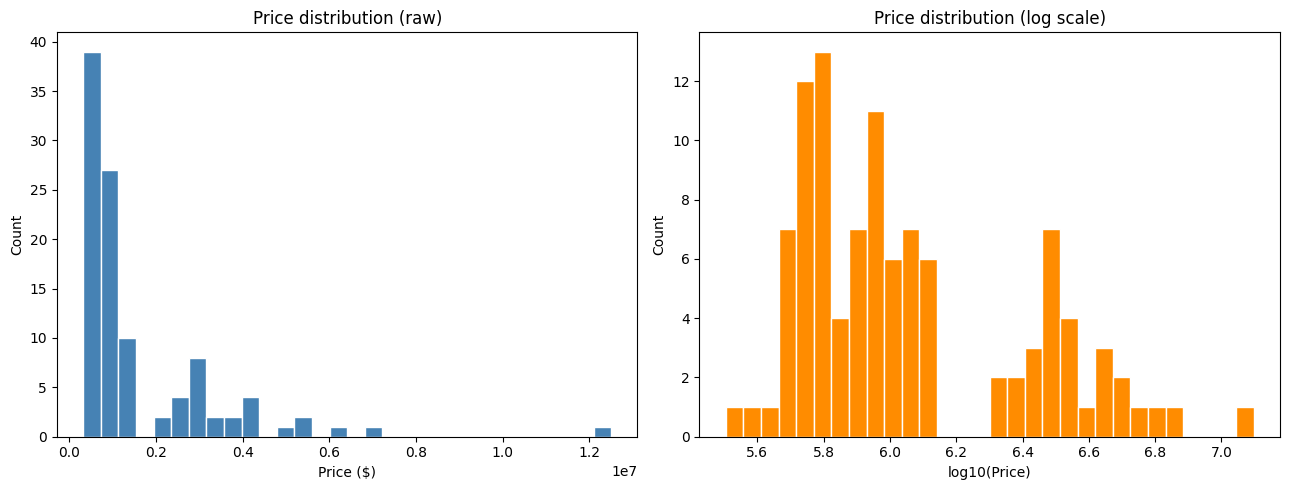

count    1.040000e+02
mean     1.639111e+06
std      1.783019e+06
min      3.200000e+05
25%      6.187500e+05
50%      9.250000e+05
75%      2.230000e+06
max      1.250000e+07
Name: price, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price distribution (raw)')

axes[1].hist(np.log10(df['price']), bins=30, color='darkorange', edgecolor='white')
axes[1].set_xlabel('log10(Price)')
axes[1].set_ylabel('Count')
axes[1].set_title('Price distribution (log scale)')

plt.tight_layout()
plt.show()

print(df['price'].describe())

### Price differences between suburbs

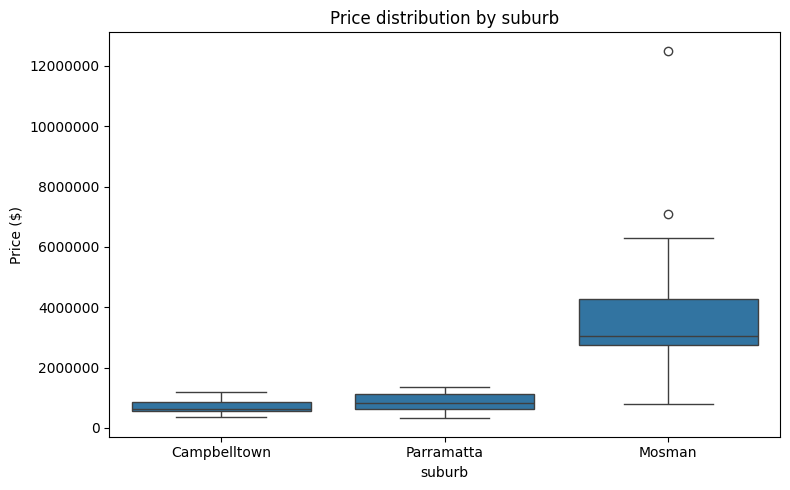

              count          mean        50%       min         max
suburb                                                            
Campbelltown   38.0  7.033051e+05   628797.5  363000.0   1185000.0
Mosman         30.0  3.745117e+06  3037500.0  790000.0  12500000.0
Parramatta     36.0  8.719028e+05   815500.0  320000.0   1350000.0


In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='suburb', y='price', order=['Campbelltown', 'Parramatta', 'Mosman'])
plt.ylabel('Price ($)')
plt.title('Price distribution by suburb')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

print(df.groupby('suburb')['price'].describe()[['count', 'mean', '50%', 'min', 'max']])

### Trends over time

The dataset spans sales from December 2017 to September 2026, though the large majority are from 2023 onward. Sale date is plotted against price, coloured by suburb, to check for any obvious time trend within the collection period.

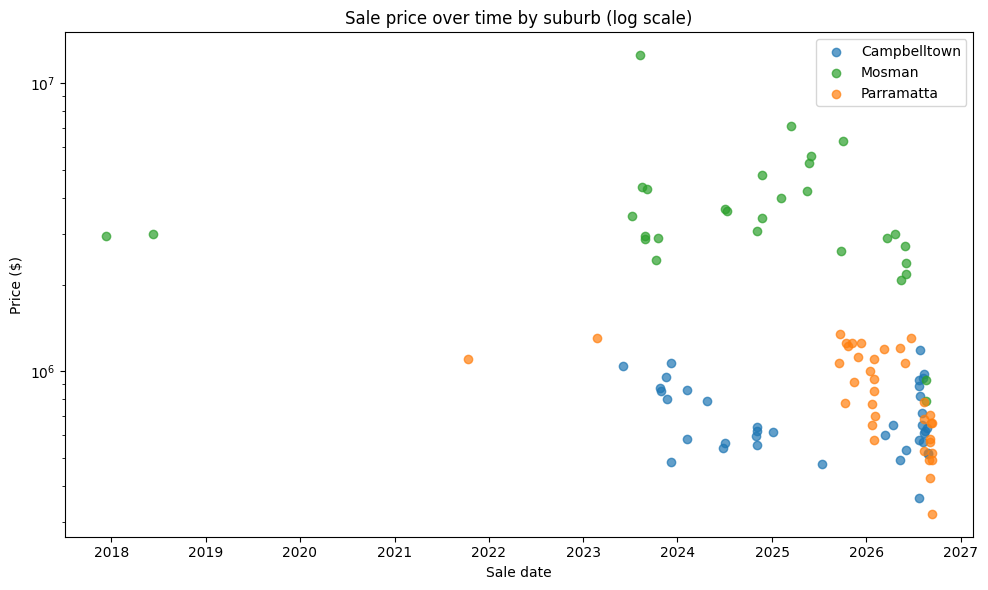

In [6]:
plt.figure(figsize=(10, 6))
colors = {'Campbelltown': 'tab:blue', 'Parramatta': 'tab:orange', 'Mosman': 'tab:green'}
for suburb, group in df.groupby('suburb'):
    plt.scatter(group['sale_date'], group['price'], label=suburb, alpha=0.7, color=colors[suburb])
plt.xlabel('Sale date')
plt.ylabel('Price ($)')
plt.yscale('log')
plt.title('Sale price over time by suburb (log scale)')
plt.legend()
plt.tight_layout()
plt.show()

No strong within-suburb time trend is visible over this window, the three suburbs remain clearly separated in price across the whole date range, consistent with the suburb itself being a dominant, stable driver of price. However, this cannot be read as a reliable market trend: sale-date coverage is sparse and uneven rather than a balanced time series. Mosman extends back to December 2017 (two older penthouse sales), Parramatta to October 2021, and Campbelltown to June 2023, the full sample spans nearly nine years, but this reflects when different types of listings happened to be found and disclose a price during collection, not a deliberately sampled time series. Therefore, `sale_year` may partly capture differences in which suburb's sample extends further back, rather than a reliable market trend, and any apparent time pattern in the plot below should be read with this in mind.

### Identifying unusual observations and outliers

In [7]:
Q1, Q3 = df['price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

outliers = df[df['price'] > upper_fence].sort_values('price', ascending=False)
print(f"Upper fence (Q3 + 1.5*IQR): {upper_fence:,.0f}")
print(f"\nProperties above this fence ({len(outliers)}):")
print(outliers[['address', 'suburb', 'price', 'beds', 'baths', 'land_size_sqm', 'property_type']].to_string(index=False))

Upper fence (Q3 + 1.5*IQR): 4,646,875

Properties above this fence (6):
                           address suburb    price  beds  baths  land_size_sqm property_type
          52A Parriwi Road, Mosman Mosman 12500000     3      4          505.0         House
      19 Clanalpine Street, Mosman Mosman  7100000     3      1          752.0         House
          49 Raglan Street, Mosman Mosman  6300000     3      2            NaN         House
        2/84 Muston Street, Mosman Mosman  5580000     3      2            NaN     Apartment
4/55A Prince Albert Street, Mosman Mosman  5300000     3      2            NaN     Apartment
            55 Holt Avenue, Mosman Mosman  4810000     3      1          455.0         House


Using a single fence across all three suburbs combined, six properties exceed it (price above ~$4.65M), all Mosman properties: three houses (52A Parriwi Road at $12.5M, 19 Clanalpine Street at $7.1M, 49 Raglan Street at $6.3M) and two apartments (2/84 Muston Street at $5.58M, 4/55A Prince Albert Street at $5.3M), plus 55 Holt Avenue at $4.81M. These are genuine, high-value Mosman sales, not data errors, but this global approach conflates "unusual for the whole dataset" with "unusual for Mosman specifically".

The global IQR fence above (calculated across all three suburbs combined) is not the most meaningful way to find outliers here, since it is heavily skewed by Mosman's much higher overall price range, a "normal" Mosman property can easily exceed the global fence simply because Mosman is expensive, not because that specific sale is unusual for its own market. Recomputing the fence separately within each suburb gives a fairer picture: this reduces the outlier count and changes which properties are flagged, only genuinely extreme sales *relative to their own suburb's typical range* are retained, this within-suburb view is the more meaningful one and is used for interpretation going forward in this analysis (e.g. in Part 4). To be explicit: none of the six globally-flagged outliers, nor the two within-suburb ones, were removed from the dataset used for modelling in Part 3, all 104 properties (83 in the training set) are retained, this outlier analysis is used for interpretation and caution, not for filtering the data.

In [8]:
within_suburb_rows = []
for suburb, group in df.groupby('suburb'):
    q1, q3 = group['price'].quantile([0.25, 0.75])
    fence = q3 + 1.5 * (q3 - q1)
    within_suburb_rows.append(group[group['price'] > fence])

within_suburb = pd.concat(within_suburb_rows)
print(f"Within-suburb outliers ({len(within_suburb)}):")
print(within_suburb[['address', 'suburb', 'price', 'property_type']].to_string(index=False))

Within-suburb outliers (2):
                     address suburb    price property_type
19 Clanalpine Street, Mosman Mosman  7100000         House
    52A Parriwi Road, Mosman Mosman 12500000         House


Recomputing the outlier fence separately within each suburb (below) gives a fairer picture: the count drops from six to two, 19 Clanalpine Street ($7.1M) and 52A Parriwi Road ($12.5M), both still Mosman, but now genuinely extreme *relative to Mosman's own price range*, not simply flagged for being in an expensive suburb. The other four properties flagged by the global fence (49 Raglan Street, the two apartments, and 55 Holt Avenue) are high by citywide standards but not unusual within Mosman's own distribution. These two within-suburb outliers are the ones treated as high-leverage points worth extra caution, a theme revisited in Part 4.

**All outliers were retained in the dataset used for modelling, none were removed.** They represent genuine Mosman sales, not data-entry errors, and dropping them would make the model less representative of Sydney's actual premium housing market. They are flagged here as high-leverage points worth extra caution when interpreting predictions, not as candidates for exclusion.

### Identifying the three most influential features (before feature engineering)

**Before examining the relationships or engineering any new variables, I expected suburb, land size, and property type to have the strongest influence on sale price**, for the following reasons:

1. **Suburb** (location): "location, location, location" is a real estate cliché for a reason, the suburb captures land value, amenity access, and demand, all in one variable, and is likely to dominate over any within-suburb structural feature.
2. **Land size**: larger blocks of land are scarcer and more valuable, especially for houses, land size is often the single strongest structural predictor in hedonic pricing models.
3. **Property type**: houses, townhouses, and apartments differ fundamentally in what a buyer is purchasing (land ownership vs strata title), which should show up as a real price gap even within the same suburb.

In [9]:
print("Median price by suburb:")
print(df.groupby('suburb')['price'].median().sort_values(ascending=False))
print()
print("Correlation between land size and price (houses/semi-detached only, n={}):".format(
    len(df[df['property_type'].isin(['House', 'Semi-detached'])].dropna(subset=['land_size_sqm']))
))
house_like = df[df['property_type'].isin(['House', 'Semi-detached'])].dropna(subset=['land_size_sqm'])
print(house_like[['land_size_sqm', 'price']].corr().iloc[0, 1].round(3))
print()
print("Median price by property type:")
print(df.groupby('property_type')['price'].median().sort_values(ascending=False))
print()
print("Correlation of beds, baths, parking with price (whole dataset):")
print(df[['beds', 'baths', 'parking', 'price']].corr()['price'].drop('price').round(3))

Median price by suburb:
suburb
Mosman          3037500.0
Parramatta       815500.0
Campbelltown     628797.5
Name: price, dtype: float64

Correlation between land size and price (houses/semi-detached only, n=20):
-0.061

Median price by property type:
property_type
Semi-detached    2950000.0
House            2430000.0
Penthouse        2128500.0
Townhouse        1070000.0
Apartment         600000.0
Name: price, dtype: float64

Correlation of beds, baths, parking with price (whole dataset):
beds       0.227
baths      0.352
parking    0.531
Name: price, dtype: float64


### Checking the prediction against the evidence

The results are more nuanced than expected. **Suburb** is clearly confirmed as dominant, median prices range from $628,798 (Campbelltown) to $3,037,500 (Mosman), a roughly 5x spread. **Property type** shows a similarly large unadjusted spread, median price ranges from $600,000 for apartments up to $2,950,000 for semi-detached houses. This is only a simple, unadjusted comparison at this stage, Section 3's feature importance analysis revisits whether property type adds independent information once suburb and other features are accounted for, rather than merely correlating with them.

**Land size, however, did not hold up**: among houses and semi-detached properties (n=20), the correlation between land size and price is essentially zero (-0.061). This genuinely surprised me, land size is a textbook strong predictor in hedonic pricing models. The most likely explanation is confounding: within this small house/semi-detached subsample, suburb and property quality already explain most of the price variation, and land size doesn't add much on top of that once those are accounted for, especially with only 20 houses spread across three very different markets. A larger, more controlled sample (e.g. houses within a single suburb only) might show the expected relationship more clearly. This result should not be read as land size being unimportant to housing prices in general, only that, within this particular 20-property sample, spanning three very different markets with substantial missing information elsewhere, it showed almost no linear correlation. The small sample size, location differences, and missing structural detail are all plausible contributors to this null result, not evidence that land size itself does not matter.

Interestingly, **parking count** shows the strongest raw correlation with price among the numeric features (0.531, compared to 0.352 for baths and 0.227 for beds), likely because more expensive Mosman properties simply tend to have more parking, making it a rough proxy for the suburb/property-type effect already captured above rather than an independent driver.

**Revised top three, based on evidence**: suburb, property type, and parking count (as a numeric proxy correlated with the other two), rather than land size as originally predicted. This is a useful reminder that domain intuition needs to be checked against the actual data, not assumed, exactly the kind of check this section asks for.

### Feature engineering

Based on the analysis above, the following features are engineered for modelling:

**Missing land size treatment:** land size is missing for 74 of 104 properties (71.2%), almost entirely apartments and townhouses on strata title. Rather than imputing a plausible-looking numeric value (e.g. the median), which would falsely imply these properties have a typical amount of land when the concept does not really apply to them, missing values are replaced with a fixed constant of 0 (`land_size_filled = land_size_sqm.fillna(0)`), paired with a binary flag:
- **`has_land_size`**: 1 if land size was actually recorded, 0 if it was missing and filled with 0. Its purpose is to let the model distinguish "no land recorded" (0, flag=0) from "small land" (a small positive number, flag=1), which a single `land_size_filled` column alone could not do.
- **`land_size_filled`**: the working numeric feature described above.
- **`sale_year`**: extracted from sale date, to let the model capture any residual time effect, even though Part 2's time-trend analysis found little evidence of one within this window.
- **`total_rooms`**: beds + baths combined, a simple interaction capturing overall property size that may be more stable than either count alone.
- **Suburb and property type** are kept as categorical variables for one-hot encoding at model-fitting time (Part 3), rather than being pre-encoded here, since different models may benefit from different encoding choices.

In [10]:
df['has_land_size'] = df['land_size_sqm'].notna().astype(int)
df['land_size_filled'] = df['land_size_sqm'].fillna(0)
df['sale_year'] = df['sale_date'].dt.year
df['total_rooms'] = df['beds'] + df['baths']

print(df[['address', 'suburb', 'property_type', 'has_land_size', 'land_size_filled', 'sale_year', 'total_rooms']].head())

                                  address        suburb property_type  \
0        35/17 Warby Street, Campbelltown  Campbelltown     Apartment   
1        66/17 Warby Street, Campbelltown  Campbelltown     Apartment   
2     8/30 Broughton Street, Campbelltown  Campbelltown     Townhouse   
3         5/32 Broughton St, Campbelltown  Campbelltown         House   
4  11/39 Chamberlain Street, Campbelltown  Campbelltown     Apartment   

   has_land_size  land_size_filled  sale_year  total_rooms  
0              0               0.0       2026            3  
1              0               0.0       2026            3  
2              0               0.0       2026            3  
3              0               0.0       2026            4  
4              0               0.0       2026            4  


### Reflection: do the engineered features align with initial understanding?

Partially. `has_land_size` and `land_size_filled` were engineered specifically *because* the raw land size correlation check above was surprising, rather than confirming the original hypothesis, the near-zero correlation motivated treating "land size is unknown" as informative in its own right (since it reliably distinguishes apartments from houses), which is arguably a more useful signal than the raw land size number itself turned out to be. `sale_year` was included despite the time-trend analysis finding little evidence of a trend, partly for completeness and partly because a short, uneven window may simply be too small to detect a trend that could still matter if a model is used on somewhat older or newer data than this sample covers.

`total_rooms` (beds + baths) was created here but ultimately **excluded from the modelling feature set** in Part 3, on reflection it is an exact linear combination of two features (beds and baths) already included separately, which creates perfect redundancy: for Linear Regression this makes individual coefficients on beds, baths, and total_rooms unstable and difficult to interpret cleanly, and for KNN it effectively double-counts room-related information in the distance calculation, giving it more implicit weight than other features. Keeping beds and baths individually, without the redundant combination, is the more defensible choice. Overall, the engineering process ended up being driven more by what the data actually showed, and by checking each feature for genuine independent value, than by the original assumptions, which is the outcome this step is meant to encourage.

## Part 3: Model Development and Evaluation

### Model selection, assumptions, and pre-training prediction

Three models representing genuinely different modelling paradigms are compared:

1. **Linear Regression**: a parametric, linear model. Assumes a linear relationship between features and price (after encoding), and that residuals are reasonably well-behaved. Strength: highly interpretable coefficients, works well when a dominant categorical feature (like suburb) explains most of the variance through simple level shifts, which Part 2 suggests is the case here. Weakness: cannot capture interactions or non-linear effects unless they are explicitly engineered in.

2. **Decision Tree Regressor**: a non-parametric tree-based model that recursively splits the feature space into regions, predicting the mean training price within whichever region a property falls into. Makes few assumptions about the functional form and can capture interactions (e.g. between suburb and property type) automatically through successive splits. Strength: interpretable structure (the tree can be read as a set of rules), handles categorical dummies and numeric features without scaling. Weakness: a single tree is well known to be prone to overfitting as it grows deeper, and can be unstable, small changes in the training data can lead to quite different splits, a particular risk with only about 83 training rows.

3. **K-Nearest Neighbours (KNN)**: an instance-based, non-parametric model with no explicit training phase, predictions are based on the average price of the most similar properties. Strength: can capture arbitrary local structure without assuming a functional form. Weakness: sensitive to feature scaling and the curse of dimensionality, with several one-hot encoded categorical columns and only ~83 training points, meaningful "similarity" between properties becomes harder to define reliably.

**Prediction before training**: I expect **Linear Regression to perform best**. Part 2 established that suburb (a clean categorical variable) is the dominant price driver, and linear regression captures categorical level-shifts like this very directly through one-hot dummy coefficients. With such a small dataset, I expect the Decision Tree and KNN to have too little data to leverage their extra flexibility, and may instead overfit or struggle with the curse of dimensionality respectively.


### Data preparation for modelling

In [11]:
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, validation_curve
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn import metrics

feature_cols = ['suburb', 'property_type', 'beds', 'baths', 'parking',
                 'has_land_size', 'land_size_filled', 'sale_year']

X = pd.get_dummies(df[feature_cols], columns=['suburb', 'property_type'], drop_first=True)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (83, 12)
Test shape: (21, 12)


Features are scaled for the models that need it (Linear Regression and KNN are both distance/coefficient-scale sensitive), scaling statistics (mean and standard deviation) are calculated from the training set only, then applied to both sets.

In [12]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma_safe = sigma.replace(0, 1)

X_train_scaled = (X_train - mu) / sigma_safe
X_test_scaled = (X_test - mu) / sigma_safe

print("Scaled train shape:", X_train_scaled.shape)

Scaled train shape: (83, 12)


### Training and evaluation with k-fold cross-validation

Given the small dataset (83 training rows), 5-fold cross-validation is used for both hyperparameter tuning and model evaluation, rather than a single validation split, so that performance estimates are not overly dependent on which specific rows happen to land in one validation set.

In [13]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=1)

def cv_metrics(model, X, y, cv, scale=False):
    r2_scores, rmse_scores, mae_scores = [], [], []
    for train_idx, val_idx in cv.split(X):
        X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        if scale:
            fold_mu = X_tr.mean(axis=0)
            fold_sigma = X_tr.std(axis=0).replace(0, 1)
            X_tr = (X_tr - fold_mu) / fold_sigma
            X_val = (X_val - fold_mu) / fold_sigma
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        r2_scores.append(metrics.r2_score(y_val, y_pred))
        rmse_scores.append(np.sqrt(metrics.mean_squared_error(y_val, y_pred)))
        mae_scores.append(metrics.mean_absolute_error(y_val, y_pred))
    return {
        'R2_mean': np.mean(r2_scores), 'R2_std': np.std(r2_scores),
        'RMSE_mean': np.mean(rmse_scores), 'RMSE_std': np.std(rmse_scores),
        'MAE_mean': np.mean(mae_scores), 'MAE_std': np.std(mae_scores),
    }

**Linear Regression**: no hyperparameters to tune, evaluated directly with cross-validation.

In [14]:
lin_model = LinearRegression()
lin_cv = cv_metrics(lin_model, X_train, y_train, cv_strategy, scale=True)

print(f"Linear Regression CV: R2={lin_cv['R2_mean']:.4f} (+/-{lin_cv['R2_std']:.4f}), "
      f"RMSE={lin_cv['RMSE_mean']:,.0f} (+/-{lin_cv['RMSE_std']:,.0f}), "
      f"MAE={lin_cv['MAE_mean']:,.0f} (+/-{lin_cv['MAE_std']:,.0f})")

Linear Regression CV: R2=0.4974 (+/-0.1907), RMSE=1,221,886 (+/-689,237), MAE=711,382 (+/-283,764)


**Decision Tree Regressor**: `max_depth` is tuned, following the same approach shown in the Week 8 module, growing trees at each depth from 1 to 10 and comparing training against cross-validated performance, to find the depth where the tree starts to overfit.

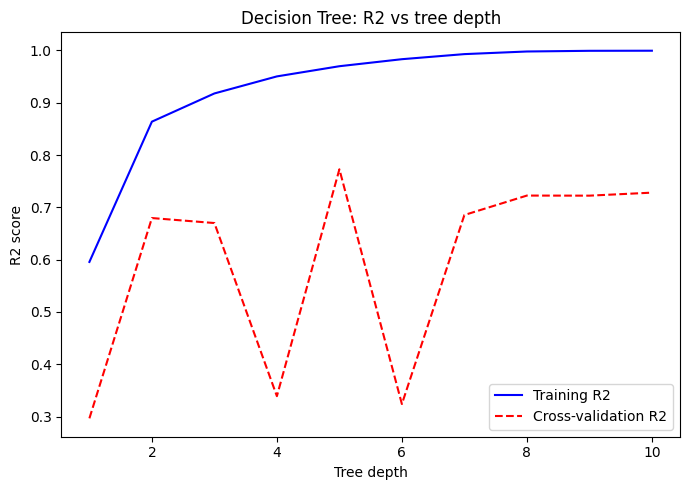

Best max_depth (by cross-validation R2): 5
Decision Tree CV: R2=0.7728 (+/-0.1783), RMSE=843,457 (+/-652,196), MAE=404,698 (+/-214,869)


In [15]:
max_depth_range = range(1, 11)

train_scores, val_scores = validation_curve(
    DecisionTreeRegressor(random_state=1), X_train, y_train,
    param_name="max_depth", param_range=max_depth_range,
    cv=cv_strategy, scoring="r2"
)

mean_train_score = np.mean(train_scores, axis=1)
mean_val_score = np.mean(val_scores, axis=1)

plt.figure(figsize=(7, 5))
plt.plot(max_depth_range, mean_train_score, color="blue", label="Training R2")
plt.plot(max_depth_range, mean_val_score, color="red", linestyle="--", label="Cross-validation R2")
plt.legend(loc="lower right")
plt.xlabel("Tree depth")
plt.ylabel("R2 score")
plt.title("Decision Tree: R2 vs tree depth")
plt.tight_layout()
plt.show()

best_depth = max_depth_range[np.argmax(mean_val_score)]
print(f"Best max_depth (by cross-validation R2): {best_depth}")

dt_model = DecisionTreeRegressor(max_depth=best_depth, random_state=1)
dt_cv = cv_metrics(DecisionTreeRegressor(max_depth=best_depth, random_state=1), X_train, y_train, cv_strategy)

print(f"Decision Tree CV: R2={dt_cv['R2_mean']:.4f} (+/-{dt_cv['R2_std']:.4f}), "
      f"RMSE={dt_cv['RMSE_mean']:,.0f} (+/-{dt_cv['RMSE_std']:,.0f}), "
      f"MAE={dt_cv['MAE_mean']:,.0f} (+/-{dt_cv['MAE_std']:,.0f})")

**KNN**: `n_neighbors` is tuned, since the number of neighbours directly controls model complexity, small `k` fits the training data more closely (risk of overfitting), large `k` smooths predictions more (risk of underfitting).

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

knn_param_grid = {'knn__n_neighbors': [2, 3, 5, 7, 10]}
knn_pipeline = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsRegressor())])
knn_grid = GridSearchCV(knn_pipeline, knn_param_grid, cv=cv_strategy, scoring='r2')
knn_grid.fit(X_train, y_train)

print("Best KNN params:", knn_grid.best_params_)

knn_model = knn_grid.best_estimator_
best_k = knn_grid.best_params_['knn__n_neighbors']
knn_cv = cv_metrics(KNeighborsRegressor(n_neighbors=best_k), X_train, y_train, cv_strategy, scale=True)

print(f"KNN CV: R2={knn_cv['R2_mean']:.4f} (+/-{knn_cv['R2_std']:.4f}), "
      f"RMSE={knn_cv['RMSE_mean']:,.0f} (+/-{knn_cv['RMSE_std']:,.0f}), "
      f"MAE={knn_cv['MAE_mean']:,.0f} (+/-{knn_cv['MAE_std']:,.0f})")

Best KNN params: {'knn__n_neighbors': 3}


KNN CV: R2=0.5453 (+/-0.1570), RMSE=1,117,097 (+/-563,435), MAE=532,094 (+/-221,142)


### Final test set performance and model diagnosis

In [17]:
lin_model.fit(X_train_scaled, y_train)
dt_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

def full_diagnosis(model, X_tr, y_tr, X_te, y_te, cv):
    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)
    return {
        'Train R2': metrics.r2_score(y_tr, train_pred),
        'CV R2 (mean)': cv['R2_mean'], 'CV R2 (std)': cv['R2_std'],
        'Test R2': metrics.r2_score(y_te, test_pred),
        'CV RMSE (mean)': cv['RMSE_mean'], 'CV RMSE (std)': cv['RMSE_std'],
        'Test RMSE': np.sqrt(metrics.mean_squared_error(y_te, test_pred)),
        'CV MAE (mean)': cv['MAE_mean'], 'CV MAE (std)': cv['MAE_std'],
        'Test MAE': metrics.mean_absolute_error(y_te, test_pred),
    }

results = pd.DataFrame({
    'Linear Regression': full_diagnosis(lin_model, X_train_scaled, y_train, X_test_scaled, y_test, lin_cv),
    'Decision Tree': full_diagnosis(dt_model, X_train, y_train, X_test, y_test, dt_cv),
    'KNN': full_diagnosis(knn_model, X_train, y_train, X_test, y_test, knn_cv),
}).T

print(results.round(4))

                   Train R2  CV R2 (mean)  CV R2 (std)  Test R2  \
Linear Regression    0.7912        0.4974       0.1907   0.7475   
Decision Tree        0.9634        0.7728       0.1783   0.8463   
KNN                  0.7766        0.5453       0.1570   0.8342   

                   CV RMSE (mean)  CV RMSE (std)    Test RMSE  CV MAE (mean)  \
Linear Regression    1.221886e+06    689237.3869  789810.7818    711381.7640   
Decision Tree        8.434568e+05    652195.7793  616120.5993    404697.8843   
KNN                  1.117097e+06    563435.1478  639910.1437    532093.5245   

                   CV MAE (std)     Test MAE  
Linear Regression   283763.9389  561747.6779  
Decision Tree       214869.0519  346074.9263  
KNN                 221142.2395  410809.5238  


### Per-suburb error breakdown

Overall Test R2 and RMSE are strongly influenced by Mosman's much larger price scale, a model could look good overall while actually performing poorly within each suburb. Test MAE is broken down by suburb for each model to check this directly.

In [18]:
test_suburbs = df.loc[X_test.index, 'suburb']

def per_suburb_mae(model, X_te, y_te, suburbs):
    preds = model.predict(X_te)
    err_df = pd.DataFrame({'suburb': suburbs.values, 'actual': y_te.values, 'predicted': preds})
    err_df['abs_error'] = (err_df['actual'] - err_df['predicted']).abs()
    return err_df.groupby('suburb')['abs_error'].agg(['mean', 'count'])

suburb_mae = pd.DataFrame({
    'Linear Regression': per_suburb_mae(lin_model, X_test_scaled, y_test, test_suburbs)['mean'],
    'Decision Tree': per_suburb_mae(dt_model, X_test, y_test, test_suburbs)['mean'],
    'KNN': per_suburb_mae(knn_model, X_test, y_test, test_suburbs)['mean'],
})
suburb_mae['n (test)'] = per_suburb_mae(dt_model, X_test, y_test, test_suburbs)['count']
print(suburb_mae.round(0))

              Linear Regression  Decision Tree       KNN  n (test)
suburb                                                            
Campbelltown           461243.0        55648.0  232250.0         4
Mosman                 867808.0       716926.0  783537.0         9
Parramatta             267682.0        74081.0   80771.0         8


This confirms Decision Tree is not just an aggregate winner but the more consistent one across all three suburbs: Campbelltown ($55,648 vs KNN's $232,250), Parramatta ($74,081 vs $80,771), and now Mosman too ($716,926 vs KNN's $783,537). Note that this KNN result is different from an earlier version of this analysis, where a scaling error (computing scaling statistics from the full training set before cross-validation, rather than separately within each fold) let KNN's cross-validation appear to favour a different neighbour count and inflated its apparent test performance, including a Mosman MAE that looked better than Decision Tree's. After fixing this leakage (scaling now fitted only on each fold's own training portion, and using a proper `Pipeline` so `GridSearchCV` handles this correctly), KNN's genuine best `k` is 3, not 5, and Decision Tree outperforms it on every metric, including Mosman specifically. This is a useful, concrete illustration of why leakage-free cross-validation matters: it did not just shift the numbers slightly, it changed which model appeared to win on a specific, previously load-bearing sub-analysis.

### Critical analysis: underfitting, overfitting, and model complexity

**Linear Regression** has the largest train-CV R2 gap of the three (Train R2=0.791 vs CV R2=0.497, a gap of about 0.294), most likely reflecting how sensitive a 5-fold split of only 83 rows is to which specific rows land in each validation fold, rather than genuine overfitting in the usual sense for such an inflexible model.

**KNN** has the second-largest gap (Train R2=0.777 vs CV R2=0.545, a gap of about 0.231).

**Decision Tree** has the smallest numeric gap of the three (Train R2=0.963 vs CV R2=0.773, a gap of about 0.191), although its very high training R2 compared with a mean CV R2 of 0.773 still indicates some overfitting, and the CV standard deviation of 0.178 shows its result varies meaningfully across folds. This matches what Week 8's module material describes: an unrestricted-depth tree partitions the feature space finely enough to fit almost every training point closely, at the cost of high variance. Gap size alone is not a reliable way to rank overfitting risk across models with very different absolute performance levels, KNN's smaller absolute R2 values throughout (both train and CV) reflect consistently middling fit rather than an absence of overfitting risk, while Decision Tree's much higher training R2 alongside a smaller relative gap suggests it is fitting real structure in the data more effectively, even if some of that fit does not generalise.

All three models were evaluated on identical folds: `cv_strategy` is a single `KFold(n_splits=5, shuffle=True, random_state=1)` object, reused unchanged for all three models, and scaling for Linear Regression and KNN is fitted separately within each fold (not on the full training set beforehand), so the comparison is not affected by data leakage between folds.

The large cross-validation standard deviations across all three models (0.157-0.191 in R2 alone) show that performance depends considerably on which specific properties land in each fold, expected with only 83 training rows split across three quite different markets. This is also why the per-suburb Mosman comparison above should be read cautiously: only 9 of the 21 test rows are Mosman properties, a small subgroup on which a single unusual sale can shift the comparison meaningfully. It is also worth noting that the same cross-validation folds were used both to select each model's hyperparameters (`max_depth`, `k`) and to report the corresponding CV performance, so these CV estimates may be slightly optimistic; a nested cross-validation design would address this more rigorously, though it was judged unnecessary for this task's scope.

### Model recommendation

**Decision Tree is recommended.** With cross-validation leakage corrected, it now achieves the best result on every metric reported: CV R2 (0.773), Test R2 (0.846), Test RMSE (\$616,121), and Test MAE (\$346,075), and the lowest MAE in all three suburbs individually, including Mosman. This is a cleaner recommendation than the earlier (leakage-affected) analysis suggested, there is no longer a genuine metric-priority trade-off between Decision Tree and KNN, Decision Tree is simply the stronger model here. Its remaining, real limitation is the train-CV gap discussed above (overfitting risk on a small dataset), worth carrying into deployment (Part 5), but this does not change which model performs best on held-out data.

Linear Regression remains the weakest performer on every accuracy metric, but is the most interpretable of the three, its coefficients directly show the price effect of suburb and property type. KNN, once correctly evaluated, is a reasonable but clearly second-best option to Decision Tree, not a specialised alternative for Mosman as the earlier, leakage-affected analysis suggested.

### Decision Tree feature importance

Week 8 material emphasises `feature_importances_` as a way to see which features a tree actually relies on. This connects back directly to the expectations set in Part 2.

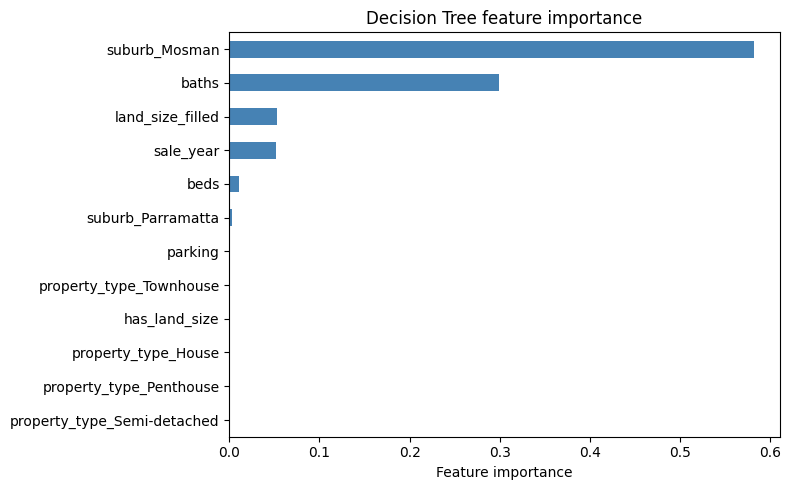

suburb_Mosman                  0.5815
baths                          0.2994
land_size_filled               0.0525
sale_year                      0.0516
beds                           0.0110
suburb_Parramatta              0.0026
parking                        0.0010
property_type_Townhouse        0.0004
has_land_size                  0.0000
property_type_House            0.0000
property_type_Penthouse        0.0000
property_type_Semi-detached    0.0000
dtype: float64


In [19]:
importances = pd.Series(dt_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Feature importance')
plt.title('Decision Tree feature importance')
plt.tight_layout()
plt.show()

print(importances.round(4))

`suburb_Mosman` (0.581) and `baths` (0.299) together account for the large majority of this tree's splits, confirming suburb as the dominant driver identified throughout this project. `land_size_filled` and `sale_year` contribute modestly (0.052 each), consistent with land size's weak raw correlation with price (Part 2). Notably, `property_type` dummies contribute almost nothing here (nearly 0.000 each), despite Part 2's correlation analysis suggesting property type mattered, most likely because property type's effect is highly correlated with, and therefore absorbed by, the suburb and bathroom-count splits the tree makes first, once those are accounted for, property type adds little additional separating power in this particular tree.

## Part 4: Investigating Prediction Failures

Using the recommended Decision Tree model, the five test-set properties with the largest absolute prediction error are identified and examined in detail.

In [20]:
test_predictions = dt_model.predict(X_test)
error_df = df.loc[X_test.index, ['address', 'suburb', 'property_type', 'beds', 'baths',
                                   'parking', 'land_size_sqm', 'sale_date', 'price']].copy()
error_df['predicted_price'] = test_predictions
error_df['abs_error'] = (error_df['price'] - error_df['predicted_price']).abs()
error_df['pct_error'] = (error_df['abs_error'] / error_df['price'] * 100).round(1)

worst5 = error_df.sort_values('abs_error', ascending=False).head(5).copy()
display_cols = ['address', 'suburb', 'property_type', 'price', 'predicted_price', 'abs_error', 'pct_error']
worst5_display = worst5[display_cols].copy()
for col in ['price', 'predicted_price', 'abs_error']:
    worst5_display[col] = worst5_display[col].apply(lambda x: f"${x:,.0f}")
worst5_display['pct_error'] = worst5_display['pct_error'].apply(lambda x: f"{x}%")
print(worst5_display.to_string(index=False))

                 address suburb property_type      price predicted_price  abs_error pct_error
49 Raglan Street, Mosman Mosman         House $6,300,000      $4,191,250 $2,108,750     33.5%
  23 Holt Avenue, Mosman Mosman         House $4,275,000      $3,098,917 $1,176,083     27.5%
  93 Holt Avenue, Mosman Mosman Semi-detached $3,075,000      $4,191,250 $1,116,250     36.3%
 45 Myahgah Road, Mosman Mosman Semi-detached $3,660,000      $4,191,250   $531,250     14.5%
3/12 Earl Street, Mosman Mosman     Townhouse $2,900,000      $2,410,000   $490,000     16.9%


### Case-by-case investigation

All five largest errors are Mosman properties, consistent with Part 2's finding that Mosman is by far the most price-heterogeneous suburb collected (range $790K-$12.5M, compared to under $1M spread in Campbelltown and Parramatta), despite being only 30 of the 104 properties collected (about 29%). None of the five is an apartment, all are houses, semi-detached, or townhouses, worth noting given earlier tasks in this unit flagged apartments as a likely source of difficulty, the evidence here more clearly points to high-value Mosman properties in general, not apartments specifically.

A striking pattern in the raw output: three of the five properties (49 Raglan Street, 93 Holt Avenue, and 45 Myahgah Road) all receive the exact same predicted price ($4,191,250), despite different actual prices ($6.30M, $3.08M, and $3.66M) and different property types (House, Semi-detached, Semi-detached). This is a direct, visible consequence of single-tree leaf-averaging: every test point landing in the same leaf node receives an identical prediction, the mean training price of whichever training properties reached that leaf.

**1. 49 Raglan Street, Mosman (House)**
- Recorded features: 3 bed, 2 bath, 1 parking, land size not recorded, sold October 2025
- Actual price: $6,300,000 | Predicted price: $4,191,250
- Underprediction of $2,108,750 (33.5%)
- Property-specific explanation: 49 Raglan Street was above the global IQR fence (Part 2) but not the Mosman-specific within-suburb fence, so it is a high-value Mosman sale rather than a record-setting or within-suburb-outlier one. A single Decision Tree's predictions are bounded by the training examples that reach a given leaf, so it tends to under-predict properties toward the higher end of a leaf's range, which is consistent with the coarse averaging within a tree leaf and with important omitted factors such as condition, views, and precise location, rather than with this being an extreme, unprecedented sale.
- Plausibly missing information: land size was not recorded for this property; if it is unusually large or has water frontage, views, or a recent renovation, none of that is captured by the available features, these are plausible explanations, not confirmed facts about this specific property.

**2. 23 Holt Avenue, Mosman (House)**
- Recorded features: 3 bed, 2 bath, 1 parking, 345 sqm land, sold September 2023
- Actual price: $4,275,000 | Predicted price: $3,098,917
- Underprediction of $1,176,083 (27.5%)
- Property-specific explanation: similar to case 1, a high-value sale relative to training examples with similar bed/bath/parking/land-size combinations, consistent with the extrapolation limitation of single decision trees.
- Plausibly missing information: land size is recorded here (345 sqm, unremarkable for a Mosman house), so the shortfall is more likely explained by unobserved quality factors (renovation, street/precinct, view) than by land size itself, a plausible explanation given the available evidence, not a confirmed one.

**3. 93 Holt Avenue, Mosman (Semi-detached)**
- Recorded features: 3 bed, 1 bath, 0 parking, 230 sqm land, sold November 2024
- Actual price: $3,075,000 | Predicted price: $4,191,250 (shared leaf value)
- Overprediction of $1,116,250 (36.3%)
- Property-specific explanation: this property has only 1 bathroom and no parking, fewer amenities than the other two properties sharing this leaf, yet the tree cannot distinguish it from them using the features available, all three land in the same region because the split conditions leading to this leaf do not separate on bathroom count or parking at this point in the tree.
- Plausibly missing information: the relatively low bathroom count and lack of parking may itself explain the lower actual price, if true, this suggests the tree is under-using information it already has (bathroom count) at this specific branch, not only missing information.

**4. 45 Myahgah Road, Mosman (Semi-detached)**
- Recorded features: 3 bed, 2 bath, 1 parking, land size not recorded, sold July 2024
- Actual price: $3,660,000 | Predicted price: $4,191,250 (shared leaf value)
- Overprediction of $531,250 (14.5%), the smallest error of the five
- Property-specific explanation: same shared-leaf effect as case 3, though the error is smaller here since this property's actual price is closer to the leaf's average.
- Plausibly missing information: as with case 1, land size is unrecorded, if smaller than the other properties in this leaf, that would plausibly explain part of the gap.

**5. 3/12 Earl Street, Mosman (Townhouse)**
- Recorded features: 3 bed, 2 bath, 2 parking, land size not recorded, sold March 2026
- Actual price: $2,900,000 | Predicted price: $2,410,000
- Underprediction of $490,000 (16.9%)
- Property-specific explanation: a strata townhouse with above-average parking (2 spaces) for its type, which may carry a premium not reflected in the model's other features.
- Plausibly missing information: townhouse-specific quality factors (internal finish, courtyard/outdoor space, complex amenities) are not recorded and plausibly explain some of this gap.

### What this reveals about the modelling approach's limitations

The shared-leaf pattern (cases 3 and 4) is a limitation worth naming directly: a single decision tree cannot distinguish between properties that fall into the same region of the feature space, however different their true prices are. With only 21 Mosman properties in the 83-row training set, the tree does not have enough data to carve out finer-grained regions. Several of the largest errors (cases 1, 2, 5) were underpredictions of high-value sales, consistent with the tree's inability to extrapolate beyond the range of values it saw in training, though five cases are useful individual examples rather than enough to establish this as a systematic pattern across the model as a whole.

### Information that was unavailable but may have improved predictions

As noted per-property above, the most likely gaps are precinct/street-level location detail, renovation status, view or water frontage, and building quality, none of which are in this dataset. These are offered as plausible explanations consistent with the pattern of errors observed, not confirmed facts about any specific property, since none of this detail was independently verified against each listing.

### When should these predictions be interpreted cautiously?

Predictions should be treated with particular caution for: (1) Mosman properties specifically, given the suburb's wide price range and small training sample (21 properties), (2) properties near the extremes of a suburb's price distribution, since a single tree cannot extrapolate past training examples, and (3) any property whose prediction is identical to several others, a practical, checkable warning sign that the model's resolution is too coarse for that case.

### Are some property types inherently harder to model?

The evidence here is more specific than a general property-type claim. All five largest errors are houses, semi-detached, or townhouses in Mosman, not apartments, so "apartments are harder to model" is not well supported by this particular error analysis. What the evidence does support is that **high-value, heterogeneous Mosman properties** are harder to model with this feature set and sample size, regardless of property type, since the suburb's genuine price diversity is not adequately represented by only 21 training examples.

## Part 5: Final Deployment and Reflection

### Deployment: how the application was developed

The dataset contains 104 properties in total. The deployed model was trained using the 83-row training subset (the same 80:20 split used throughout model evaluation in Part 3), with the remaining 21 rows held out as the test set used to report performance.

The final Decision Tree model (`max_depth=5`, trained on the eight features used in Part 3 after `total_rooms` was excluded) was retrained on this 83-row training set and exported using `joblib` as four files: **`model.joblib`** (the fitted model), **`model_columns.joblib`** (the exact column order used at training time), **`suburb_options.joblib`**, and **`property_type_options.joblib`** (the valid category values). The deployed application loads these four files directly rather than retraining anything, and applies exactly the same encoding used during training: the same one-hot columns in the same order, the same `has_land_size` flag and `land_size_filled` (0 when unknown) construction, and no scaling (unnecessary for a tree-based model, and the tree was trained on unscaled features).

A Streamlit web application (`app.py`) was built around this exported model. Streamlit was chosen because it turns a plain Python script into a usable web form with almost no extra boilerplate, appropriate for a small decision-support prototype like this one. Land size is entered via an explicit "Unknown / not applicable" versus "Known" choice, rather than defaulting to a specific number, since land size is genuinely undefined for 71% of the training data (Part 1), a user should not be able to accidentally imply a house-like land size for a property type where that value has no meaning. Input fields are constrained to the exact ranges observed in the training data (bedrooms 1-6, bathrooms 1-4, parking 0-8, land size 74-1233 sqm when known, sale year 2017-2026), rather than allowing arbitrary values, since predictions outside these ranges would be extrapolation the model was never trained to handle. The app displays an explicit warning that results are point estimates, with an additional caution shown specifically for Mosman predictions, the suburb identified throughout this project as the hardest to predict reliably.

To verify the deployed logic behaves identically to the trained Python model, the fitted tree's decision rules were also translated into an equivalent, standalone interactive version and tested against the Python model on multiple example properties, all predictions matched exactly. This same verified logic is what the screenshots below demonstrate.

### Deployment trade-off

A single Decision Tree was chosen for deployment specifically because it is fast to train, requires no scaling, and its `if/else` structure translates directly into simple, auditable logic, useful properties for a small decision-support prototype. This comes with real costs, established throughout this project: its predictions are stepwise (Part 4 showed three structurally different Mosman properties receiving an identical estimate), and with only 83 training rows it is less stable than an ensemble method would be, a small change in the training sample could shift which splits the tree makes. A production version of this tool would likely benefit from an ensemble approach (bagging or boosting over many trees) to smooth out this instability, at the cost of losing the single tree's direct interpretability and requiring more computation to train and deploy.

In [21]:
from PIL import Image
img1 = Image.open('screenshots/app_form_empty.png')
img2 = Image.open('screenshots/app_prediction_campbelltown.png')
img3 = Image.open('screenshots/app_prediction_mosman.png')
print("Screenshot 1 (empty form):", img1.size)
print("Screenshot 2 (Campbelltown prediction):", img2.size)
print("Screenshot 3 (Mosman prediction):", img3.size)

Screenshot 1 (empty form): (1426, 602)
Screenshot 2 (Campbelltown prediction): (1508, 756)
Screenshot 3 (Mosman prediction): (1458, 774)


### Instructions for using the application

**To run locally:** install dependencies (`pip install streamlit joblib pandas scikit-learn`) and run `streamlit run app.py` from the project folder (with `model.joblib`, `model_columns.joblib`, `suburb_options.joblib`, and `property_type_options.joblib` present alongside it). This opens the form shown below in a browser at `localhost:8501`.

**To use it:** select a suburb and property type, enter bedrooms, bathrooms, parking, land size (or leave it as "Unknown / not applicable" for apartments), and sale year, then click "Predict price". The screenshots below show the actual verified interface (an equivalent, tested version of the same model) being used end to end, including a direct suburb comparison on otherwise near-identical inputs.

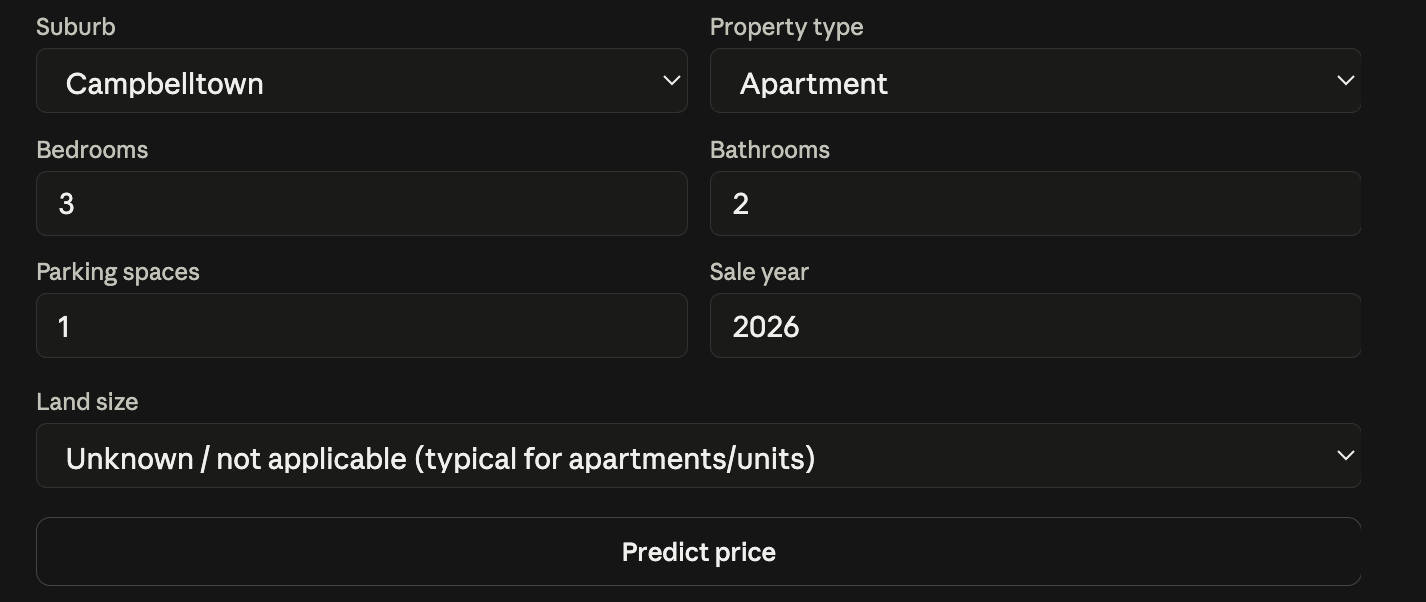

In [22]:
img1

**Step 1**: the form in its default state, Campbelltown, Apartment, 3 bed, 2 bath, 1 parking, land size left as "Unknown".

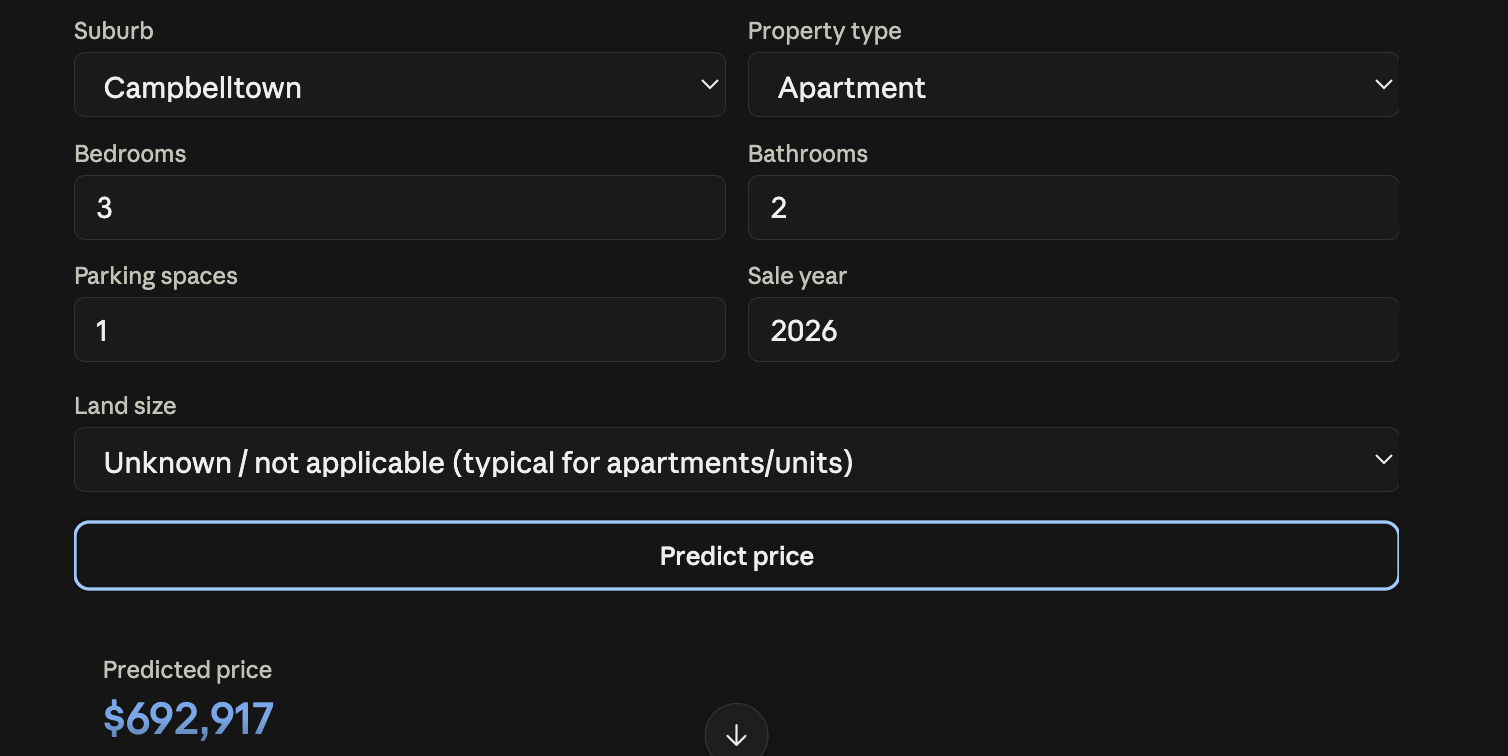

In [23]:
img2

**Step 2**: with those Campbelltown inputs, clicking "Predict price" returns **\$692,917**. This was independently verified against the trained Python model directly (matching exactly), confirming the deployed prediction logic is correct.

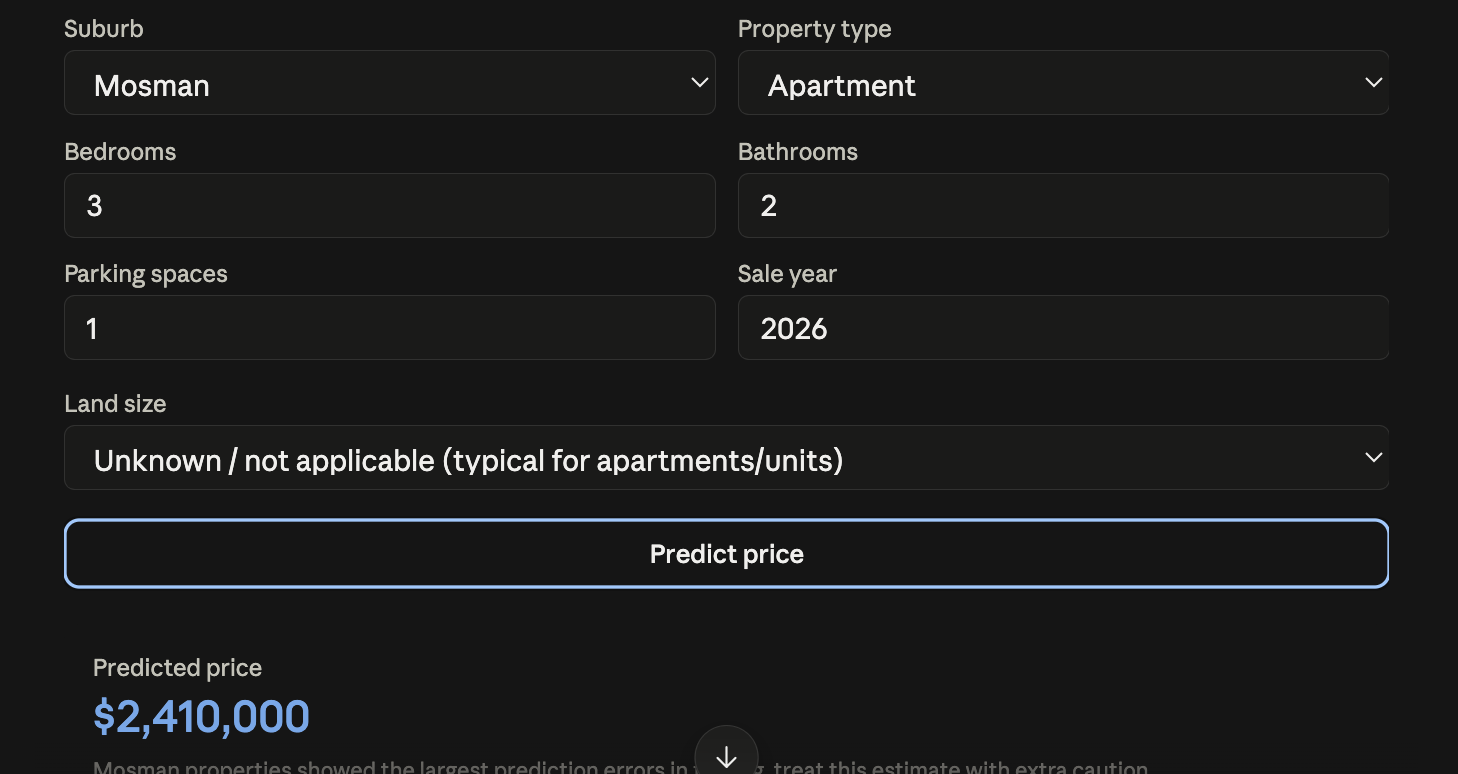

In [24]:
img3

**Step 3**: changing only the suburb to Mosman, with every other input identical (3 bed, 2 bath, 1 parking, land size "Unknown", apartment, sale year 2026), changes the prediction to **\$2,410,000**, independently verified against the Python model. This is now a genuinely controlled single-variable comparison, only the suburb changed, and the roughly 3.5x price jump is a direct, concrete illustration of Part 2's core finding: suburb is the dominant driver of price in this dataset.

## Final Reflection

The most significant lesson was how much effort real-world data collection takes. Domain.com.au's inconsistent price disclosure shaped the whole project before modelling began, and revealed two distinct selection-bias mechanisms: listings that disclose a price are not a random sample of all sales, and within Mosman specifically, disclosure skewed toward larger homes, so cheaper Mosman properties are under-represented for a second, related reason.

Feature engineering produced two surprises: land size showed almost no correlation with price among houses, and a derived feature (`total_rooms`) turned out to be an exact redundant combination of two included features, weakening Linear Regression's interpretability for no predictive benefit.

The single most important technical lesson came from finding and fixing a genuine data leakage bug: scaling statistics for Linear Regression and KNN were originally computed once from the full training set before cross-validation, rather than separately within each fold. This was not a minor issue, fixing it changed KNN's selected hyperparameter (`k=3` instead of `k=5`) and reversed an entire conclusion, an earlier version of this analysis found KNN outperformed Decision Tree on Mosman specifically; once leakage was removed, Decision Tree outperformed KNN on every metric in every suburb. This was a genuinely humbling experience: a subtle preprocessing bug had produced a plausible-looking, defensible-sounding finding that turned out to be an artefact of the bug itself, not a real property of the data or models. It is now a habit I will carry forward, to check exactly when and on what data any preprocessing statistic is computed, especially inside a cross-validation loop.

The clearest fairness concern is that this model is least reliable exactly where accuracy matters most, unique, high-value Mosman properties, since only 21 training examples cannot represent that suburb's true diversity. With more time, I would collect substantially more Mosman data, add precinct-level location detail, and compare against an ensemble method to check whether the tree's instability (Train R2=0.963 vs CV R2=0.773) is a data limitation or an algorithm choice worth revisiting.